In [39]:
# ── Cell 1: Imports & global config ──────────────────────────────
import torch
import torch.nn as nn
from torch.nn import functional as F

In [40]:
# Reproducibility — same random numbers every run
torch.manual_seed(1337)

In [41]:
# Hyperparameters
# We WILL tune these later; keeping them in one place = easy to change.
config = {
    "batch_size":   32,     # how many sequences we process in parallel
    "block_size":   64,     # max context length (chars the model "sees")
    "n_embd":       192,  # 128,    # embedding dimension (model width)
    "n_head":       4,      # number of attention heads
    "n_layer":      4,      # number of transformer blocks (depth)
    "dropout":      0.1,    # regularization
    "learning_rate": 3e-4,
    "max_iters":    5000, # 3000,   # training steps
    "eval_interval": 300,   # how often we check val loss
    "eval_iters":   200,    # batches to average for a stable loss estimate
    "device":       "cuda" if torch.cuda.is_available() else "cpu",
}

print("Running on:", config["device"])

Running on: cpu


In [42]:
# ── Cell 2: Load data & build char-level tokenizer ───────────────
with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print("Total characters:", len(text))
print("First 100 chars:\n", text[:100])

Total characters: 1115394
First 100 chars:
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [43]:
# The "vocabulary" = every unique character in the text
chars = sorted(list(set(text)))
vocab_size = len(chars)
print("\nVocab size:", vocab_size)
print("Characters:", "".join(chars))


Vocab size: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


In [44]:
# Tokenizer: map each char <-> an integer.
# This is the SIMPLEST possible tokenizer — one char = one token.
stoi = {ch: i for i, ch in enumerate(chars)}   # string-to-int
itos = {i: ch for i, ch in enumerate(chars)}   # int-to-string

In [45]:
encode = lambda s: [stoi[c] for c in s]        # "hi" -> [46, 47]
decode = lambda l: "".join([itos[i] for i in l])  # [46,47] -> "hi"

# Quick sanity check
print("\nEncoded 'hii there':", encode("hii there"))
print("Decoded back:", decode(encode("hii there")))


Encoded 'hii there': [46, 47, 47, 1, 58, 46, 43, 56, 43]
Decoded back: hii there


In [46]:
# ── Cell 3: Encode full dataset & split train/val ────────────────
# Turn the ENTIRE text into one long tensor of integers.
data = torch.tensor(encode(text), dtype=torch.long)
print("Data shape:", data.shape, "| dtype:", data.dtype)
print("First 50 tokens:", data[:50])

Data shape: torch.Size([1115394]) | dtype: torch.int64
First 50 tokens: tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56])


In [47]:
# Split: 90% train, 10% validation.
# Val set = text the model NEVER trains on, so we can honestly
# measure whether it's learning patterns vs. just memorizing.
n = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]

In [48]:
# decode(train_data[:100].tolist())
# decode(val_data[:100].tolist())

In [49]:
print("\nTrain tokens:", len(train_data))
print("Val tokens:  ", len(val_data))


Train tokens: 1003854
Val tokens:   111540


In [50]:
# ── Cell 4: Batch generator ──────────────────────────────────────
def get_batch(split):
    # Pick the right ribbon of data
    data = train_data if split == "train" else val_data

    # Random starting positions — one per sequence in the batch.
    # We need room for block_size chars + 1 (the target), so we stop
    # ix at len(data) - block_size.
    ix = torch.randint(len(data) - config["block_size"], (config["batch_size"],))

    # x = input windows;  y = same windows shifted right by 1 (the "next char")
    x = torch.stack([data[i     : i + config["block_size"]]     for i in ix])
    y = torch.stack([data[i + 1 : i + config["block_size"] + 1] for i in ix])

    x, y = x.to(config["device"]), y.to(config["device"])
    return x, y

In [51]:
# Sanity check
xb, yb = get_batch("train")
print("Inputs  x shape:", xb.shape)   # (batch_size, block_size)
print("Targets y shape:", yb.shape)   # (batch_size, block_size)
print("\nExample — first sequence in batch:")
print("x[0]:", xb[0].tolist())
print("y[0]:", yb[0].tolist())

Inputs  x shape: torch.Size([32, 64])
Targets y shape: torch.Size([32, 64])

Example — first sequence in batch:
x[0]: [50, 43, 8, 1, 32, 46, 47, 52, 49, 1, 61, 47, 58, 46, 1, 58, 46, 63, 57, 43, 50, 44, 0, 20, 53, 61, 1, 51, 53, 56, 43, 1, 59, 52, 44, 53, 56, 58, 59, 52, 39, 58, 43, 1, 58, 46, 39, 52, 1, 39, 50, 50, 1, 50, 47, 60, 47, 52, 45, 1, 61, 53, 51, 43]
y[0]: [43, 8, 1, 32, 46, 47, 52, 49, 1, 61, 47, 58, 46, 1, 58, 46, 63, 57, 43, 50, 44, 0, 20, 53, 61, 1, 51, 53, 56, 43, 1, 59, 52, 44, 53, 56, 58, 59, 52, 39, 58, 43, 1, 58, 46, 39, 52, 1, 39, 50, 50, 1, 50, 47, 60, 47, 52, 45, 1, 61, 53, 51, 43, 52]


In [52]:
# ── Cell 5: A minimal trainable model (bigram baseline) ──────────
class BigramLM(nn.Module):
    """Simplest LM: each token directly looks up the logits for the
    next token from an embedding table. No context, no attention yet —
    just 'which char tends to follow this char?'. Our baseline."""

    def __init__(self, vocab_size):
        super().__init__()
        # Row i = a vocab_size-long score vector for 'what follows token i'
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        # idx: (B, T) integers -> logits: (B, T, vocab_size)
        logits = self.token_embedding_table(idx)

        if targets is None:
            loss = None
        else:
            # Reshape so cross_entropy sees (N, vocab) vs (N,)
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)  # how wrong are we?

        return logits, loss

model = BigramLM(vocab_size).to(config["device"])
xb, yb = get_batch("train")
logits, loss = model(xb, yb)
print("Logits shape:", logits.shape)
print("Initial loss:", loss.item())
print("Expected (random) loss ≈", round(torch.log(torch.tensor(vocab_size)).item(), 3))

Logits shape: torch.Size([2048, 65])
Initial loss: 4.764299392700195
Expected (random) loss ≈ 4.174


In [53]:
# ── Cell 6a: Honest loss estimator ───────────────────────────────
@torch.no_grad()  # no gradients needed here — saves memory, faster
def estimate_loss(model):
    """Average loss over many batches = a stable, low-noise number.
    A single batch is too noisy to judge progress by."""
    out = {}
    model.eval()  # eval mode (turns off dropout etc.)
    for split in ["train", "val"]:
        losses = torch.zeros(config["eval_iters"])
        for k in range(config["eval_iters"]):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()  # back to training mode
    return out

In [54]:
# ── Cell 6b: Training loop ───────────────────────────────────────
# Optimizer = the algorithm that nudges weights to reduce loss.
# AdamW is the standard workhorse.
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

history = {"iter": [], "train": [], "val": []}  # for plotting later

for iter in range(config["max_iters"]):
    # Every so often, measure + record honest loss
    if iter % config["eval_interval"] == 0 or iter == config["max_iters"] - 1:
        losses = estimate_loss(model)
        history["iter"].append(iter)
        history["train"].append(losses["train"])
        history["val"].append(losses["val"])
        print(f"step {iter:4d} | train {losses['train']:.4f} | val {losses['val']:.4f}")

    # ── The actual learning step ──
    xb, yb = get_batch("train")        # 1. get a batch
    logits, loss = model(xb, yb)       # 2. forward pass → loss
    optimizer.zero_grad(set_to_none=True)  # 3. clear old gradients
    loss.backward()                    # 4. backprop (autograd!) → gradients
    optimizer.step()                   # 5. nudge weights to reduce loss

print("\nDone. Final loss:", round(history['val'][-1], 4))

step    0 | train 4.7746 | val 4.7711
step  300 | train 4.6425 | val 4.6456
step  600 | train 4.5182 | val 4.5220
step  900 | train 4.4022 | val 4.4065
step 1200 | train 4.2925 | val 4.2916
step 1500 | train 4.1807 | val 4.1841
step 1800 | train 4.0774 | val 4.0786
step 2100 | train 3.9763 | val 3.9815
step 2400 | train 3.8818 | val 3.8839
step 2700 | train 3.7893 | val 3.7930
step 3000 | train 3.6999 | val 3.7046
step 3300 | train 3.6179 | val 3.6241
step 3600 | train 3.5374 | val 3.5429
step 3900 | train 3.4583 | val 3.4684
step 4200 | train 3.3853 | val 3.3958
step 4500 | train 3.3214 | val 3.3299
step 4800 | train 3.2558 | val 3.2655
step 4999 | train 3.2144 | val 3.2262

Done. Final loss: 3.2262


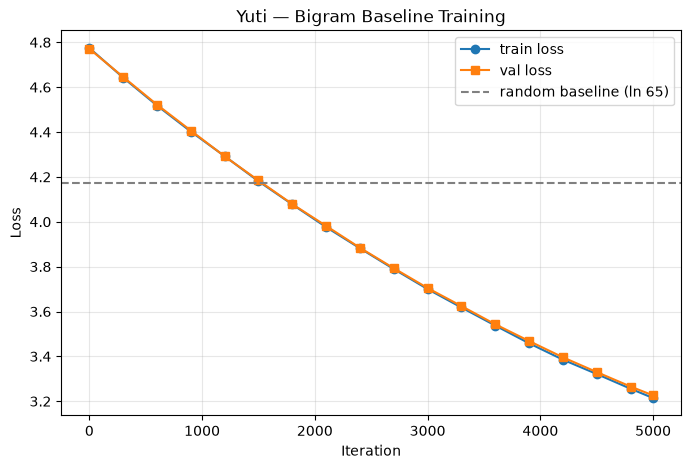

In [55]:
# ── Cell 6c: Visualize training ──────────────────────────────────
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["iter"], history["train"], label="train loss", marker="o")
plt.plot(history["iter"], history["val"],   label="val loss",   marker="s")
plt.axhline(y=torch.log(torch.tensor(vocab_size)).item(),
            color="gray", linestyle="--", label="random baseline (ln 65)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Yuti — Bigram Baseline Training")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [56]:
# ── Model summary: layers + parameter count ──────────────────────
print(model)  # prints the module structure (layers & shapes)

total = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total:,}")
for name, p in model.named_parameters():
    print(f"{name:40s} {tuple(p.shape)}  ({p.numel():,})")

BigramLM(
  (token_embedding_table): Embedding(65, 65)
)

Total parameters: 4,225
token_embedding_table.weight             (65, 65)  (4,225)


In [57]:
from torchinfo import summary
summary(model, input_data=xb)  # layer-by-layer shapes + param counts

Layer (type:depth-idx)                   Output Shape              Param #
BigramLM                                 [32, 64, 65]              --
├─Embedding: 1-1                         [32, 64, 65]              4,225
Total params: 4,225
Trainable params: 4,225
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.14
Input size (MB): 0.02
Forward/backward pass size (MB): 1.06
Params size (MB): 0.02
Estimated Total Size (MB): 1.10

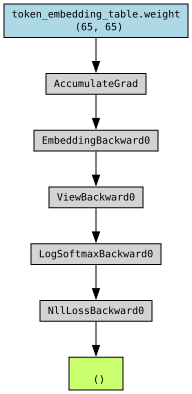

In [58]:
from torchviz import make_dot
logits, loss = model(xb, yb)
make_dot(loss, params=dict(model.named_parameters()))  # renders the autograd graph

In [59]:
# ── Model X-ray: structure + parameters ──────────────────────────
print(model)
total = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total:,}")

BigramLM(
  (token_embedding_table): Embedding(65, 65)
)

Total parameters: 4,225


In [60]:
# ── Cell 7: A single self-attention head ─────────────────────────
class Head(nn.Module):
    """One head of self-attention."""

    def __init__(self, head_size):
        super().__init__()
        # Each projects the (B,T,n_embd) input into (B,T,head_size)
        self.key   = nn.Linear(config["n_embd"], head_size, bias=False)
        self.query = nn.Linear(config["n_embd"], head_size, bias=False)
        self.value = nn.Linear(config["n_embd"], head_size, bias=False)

        # Causal mask: a lower-triangular matrix of 1s. Registered as a
        # buffer (not a trainable weight) so it moves with the model.
        self.register_buffer(
            "tril", torch.tril(torch.ones(config["block_size"], config["block_size"]))
        )
        self.dropout = nn.Dropout(config["dropout"])

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)     # (B, T, head_size)
        q = self.query(x)   # (B, T, head_size)

        # Attention scores = how much each position attends to every other.
        # Scale by 1/sqrt(head_size) to keep variance stable (softmax sanity).
        wei = q @ k.transpose(-2, -1) * k.shape[-1] ** -0.5  # (B, T, T)

        # CAUSAL MASK: block positions from seeing the FUTURE.
        # Future scores → -inf → become 0 after softmax.
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)   # normalize to weights summing to 1
        wei = self.dropout(wei)

        v = self.value(x)   # (B, T, head_size)
        out = wei @ v       # weighted sum of values → (B, T, head_size)
        return out

In [61]:
# ── Cell 8: Multi-head attention ─────────────────────────────────
class MultiHeadAttention(nn.Module):
    """Several attention heads running in parallel, then combined."""

    def __init__(self, num_heads, head_size):
        super().__init__()
        # A list of independent heads (from Cell 7)
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        # Projection: mixes the concatenated head outputs back to n_embd
        self.proj = nn.Linear(head_size * num_heads, config["n_embd"])
        self.dropout = nn.Dropout(config["dropout"])

    def forward(self, x):
        # Run every head, concatenate along the channel dim
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # (B, T, head_size*num_heads)
        out = self.dropout(self.proj(out))                   # (B, T, n_embd)
        return out

In [62]:
    # ── Cell 9: Feed-forward network ─────────────────────────────────
class FeedForward(nn.Module):
    """A simple MLP applied to each position independently.
    Attention mixes ACROSS positions; this thinks WITHIN a position."""

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),   # expand 4x (more room to compute)
            nn.ReLU(),                       # non-linearity → learn complex patterns
            nn.Linear(4 * n_embd, n_embd),   # project back to n_embd
            nn.Dropout(config["dropout"]),
        )

    def forward(self, x):
        return self.net(x)   # (B, T, n_embd) → (B, T, n_embd)

In [63]:
# ── Cell 10: One Transformer block ───────────────────────────────
class Block(nn.Module):
    """Transformer block: communication (attention) + computation (FF),
    each wrapped with a residual connection and pre-layer-norm."""

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa   = MultiHeadAttention(n_head, head_size)  # self-attention
        self.ffwd = FeedForward(n_embd)                    # feed-forward
        self.ln1  = nn.LayerNorm(n_embd)                   # norm before attention
        self.ln2  = nn.LayerNorm(n_embd)                   # norm before feed-forward

    def forward(self, x):
        # NOTE the '+ x' — residual connections.
        x = x + self.sa(self.ln1(x))    # attend, add back to input
        x = x + self.ffwd(self.ln2(x))  # think,  add back to input
        return x

In [64]:
# ── Cell 11: The full Yuti GPT model ─────────────────────────────
class YutiGPT(nn.Module):
    def __init__(self):
        super().__init__()
        # Token embedding: token id → a learnable n_embd vector ("meaning")
        self.token_embedding_table    = nn.Embedding(vocab_size, config["n_embd"])
        # Position embedding: position (0..block_size-1) → a vector ("where am I")
        self.position_embedding_table = nn.Embedding(config["block_size"], config["n_embd"])

        # The body: a stack of n_layer transformer blocks
        self.blocks = nn.Sequential(
            *[Block(config["n_embd"], config["n_head"]) for _ in range(config["n_layer"])]
        )
        self.ln_f = nn.LayerNorm(config["n_embd"])              # final layer norm
        self.lm_head = nn.Linear(config["n_embd"], vocab_size)  # → next-token logits

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)                                  # (B,T,n_embd)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))# (T,n_embd)
        x = tok_emb + pos_emb          # inject BOTH identity and position
        x = self.blocks(x)             # run through all transformer blocks
        x = self.ln_f(x)               # final norm
        logits = self.lm_head(x)       # (B, T, vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss
    
    # ── Add this method INSIDE the YutiGPT class (after forward) ──────
    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        """Given a starting context (B,T), generate max_new_tokens more."""
        for _ in range(max_new_tokens):
            # Crop context to the last block_size tokens (model's max memory)
            idx_cond = idx[:, -config["block_size"]:]
            logits, _ = self(idx_cond)          # (B, T, vocab_size)
            logits = logits[:, -1, :]           # take ONLY the last position
            probs = F.softmax(logits, dim=-1)   # scores → probabilities
            idx_next = torch.multinomial(probs, num_samples=1)  # sample 1 char
            idx = torch.cat((idx, idx_next), dim=1)  # append, feed back in
        return idx

model = YutiGPT().to(config["device"])
total = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nYuti parameters: {total:,}")

YutiGPT(
  (token_embedding_table): Embedding(65, 192)
  (position_embedding_table): Embedding(64, 192)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x Head(
            (key): Linear(in_features=192, out_features=48, bias=False)
            (query): Linear(in_features=192, out_features=48, bias=False)
            (value): Linear(in_features=192, out_features=48, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=192, out_features=768, bias=True)
          (1): ReLU()
          (2): Linear(in_features=768, out_features=192, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
      (ln1): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=

In [65]:
# ── Yuti X-ray: structure + parameter breakdown ──────────────────
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}\n")

# Params grouped by component — see where the "weight" lives
from collections import defaultdict
groups = defaultdict(int)
for name, p in model.named_parameters():
    key = name.split(".")[0]          # token_embedding_table, blocks, ln_f, lm_head
    groups[key] += p.numel()
for k, v in groups.items():
    print(f"{k:28s} {v:>8,}")

YutiGPT(
  (token_embedding_table): Embedding(65, 192)
  (position_embedding_table): Embedding(64, 192)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x Head(
            (key): Linear(in_features=192, out_features=48, bias=False)
            (query): Linear(in_features=192, out_features=48, bias=False)
            (value): Linear(in_features=192, out_features=48, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=192, out_features=768, bias=True)
          (1): ReLU()
          (2): Linear(in_features=768, out_features=192, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
      (ln1): LayerNorm((192,), eps=1e-05, elementwise_affine=True, bias=

In [66]:
from torchinfo import summary
summary(model, input_data=xb, dtypes=[torch.long])

Layer (type:depth-idx)                        Output Shape              Param #
YutiGPT                                       [32, 64, 65]              --
├─Embedding: 1-1                              [32, 64, 192]             12,480
├─Embedding: 1-2                              [64, 192]                 12,288
├─Sequential: 1-3                             [32, 64, 192]             --
│    └─Block: 2-1                             [32, 64, 192]             --
│    │    └─LayerNorm: 3-1                    [32, 64, 192]             384
│    │    └─MultiHeadAttention: 3-2           [32, 64, 192]             147,648
│    │    └─LayerNorm: 3-3                    [32, 64, 192]             384
│    │    └─FeedForward: 3-4                  [32, 64, 192]             295,872
│    └─Block: 2-2                             [32, 64, 192]             --
│    │    └─LayerNorm: 3-5                    [32, 64, 192]             384
│    │    └─MultiHeadAttention: 3-6           [32, 64, 192]             14

In [68]:
# ── Cell 6b: Training loop ───────────────────────────────────────
# Optimizer = the algorithm that nudges weights to reduce loss.
# AdamW is the standard workhorse.
optimizer = torch.optim.AdamW(model.parameters(), lr=config["learning_rate"])

history = {"iter": [], "train": [], "val": []}  # for plotting later

for iter in range(config["max_iters"]):
    # Every so often, measure + record honest loss
    if iter % config["eval_interval"] == 0 or iter == config["max_iters"] - 1:
        losses = estimate_loss(model)
        history["iter"].append(iter)
        history["train"].append(losses["train"])
        history["val"].append(losses["val"])
        print(f"step {iter:4d} | train {losses['train']:.4f} | val {losses['val']:.4f}")

    # ── The actual learning step ──
    xb, yb = get_batch("train")        # 1. get a batch
    logits, loss = model(xb, yb)       # 2. forward pass → loss
    optimizer.zero_grad(set_to_none=True)  # 3. clear old gradients
    loss.backward()                    # 4. backprop (autograd!) → gradients
    optimizer.step()                   # 5. nudge weights to reduce loss

print("\nDone. Final loss:", round(history['val'][-1], 4))

step    0 | train 4.3306 | val 4.3389
step  300 | train 2.3039 | val 2.3103
step  600 | train 2.0537 | val 2.0966
step  900 | train 1.9038 | val 1.9861
step 1200 | train 1.8074 | val 1.9129
step 1500 | train 1.7305 | val 1.8728
step 1800 | train 1.6772 | val 1.8313
step 2100 | train 1.6315 | val 1.7989
step 2400 | train 1.6033 | val 1.7660
step 2700 | train 1.5661 | val 1.7456
step 3000 | train 1.5471 | val 1.7110
step 3300 | train 1.5262 | val 1.7004
step 3600 | train 1.5001 | val 1.6968
step 3900 | train 1.4926 | val 1.6799
step 4200 | train 1.4831 | val 1.6707
step 4500 | train 1.4665 | val 1.6610
step 4800 | train 1.4583 | val 1.6482
step 4999 | train 1.4446 | val 1.6436

Done. Final loss: 1.6436


In [69]:
# ── Cell 12: Generate text from trained Yuti ─────────────────────
# Start with a single newline char as the seed context
context = torch.zeros((1, 1), dtype=torch.long, device=config["device"])
generated = model.generate(context, max_new_tokens=500)
print(decode(generated[0].tolist()))



LADY ANNE:
Yar, rain, in I lad prajes, and the widage.

YORK:
Away not is neir heard by my head with first thoy
To the shall peery try tope: this not Henrior!
To some, duke regree the conercy court with the royal that hand!

WARWICK:
Lady an more forby as soul thy friend.

LUCIO:
My corrance
Thy arass, ift they sorrow ham.
O Phatch, your sten sodier, for throvenes to-morrial go there of that
Where, here infold Manioner
The stunes of the newakel time, my reshoure in?

DUKE VINCENTIO:
We with dru


In [70]:
# ── Chat-ish: seed Yuti with your text, let it continue ──────────
def talk(prompt, max_new_tokens=300):
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=config["device"])
    out = model.generate(idx, max_new_tokens)
    print(decode(out[0].tolist()))

talk("ROMEO:")        # it continues as if Romeo is speaking
talk("To be or ")     # it continues the phrase

ROMEO:
Wor that have our rumpost. Would the blood!

ISABELLA:
Yor datmand most ears; where's against here in were
grave night upon thy so: of homen sworthy?

Beings, good dear damembroke him.
Do we have steep and die, in their sight the depose
One the hate thigh a grief death.ed her, is the woray!
Breed '
To be or gree hands shall arms out warrer'd
Her brother life thy welcomes: in a king-grace.
Well thou tre of the const for they wars!
That shall younder confessed on the like of news:
Now on pronate for Engled their potrify:
But heart again. How dost where is thing wpron they
present his vingery of hands nob
